# Error propagation

When performing image calibrations, `opticam` handles the error propagation for you. In this notebook, I will prove that `opticam`'s error propagation is correct.

## Generating data

First, we need to generate some data that contain only noise. We will include typical values for the bias and dark current, and simulate long exposures to allow for a significant dark noise contribution. We will also generate flat-field images, which introduce some additional noise. These images will be generated as if they were produced by OPTICAM-MX, but we'll only simulate data from a single camera for simplicity.

Let's define the properties of these generated data: 

In [1]:
X, Y = 512, 512  # image dimensions

gain = 1.  # gain of OPTICAM-MX
read_noise = 1.1  # nominal read noise of OPTICAM-MX
dark_curr = 0.1  # nominal dark current of OPTICAM-MX
texp = 30.  # exposure time in seconds
fltr = 'g'  # image filter

binning = f'{2048 // X}x{2048 // Y}'  # binning mode

bias_value = 400.  # typical bias according to Handbook of CCD Astronomy, Howell

flat_level = 40000.  # mean flux of flats

dark_signal = dark_curr * texp  # compute exposure-integrated dark current (dark noise contribution)

n_calibration_images = 50  # number of images to generate for each calibration step

science_flux = 1000  # mean flux in science images before noise

We can compute the analytical variances for each calibration:

In [2]:
import numpy as np

true_bias_var = read_noise**2 / n_calibration_images
true_dark_var = np.pi / 2 * (dark_signal + read_noise**2 + true_bias_var) / n_calibration_images
true_flat_var = np.pi / 2 * (flat_level + read_noise**2 + true_bias_var) / n_calibration_images / flat_level**2
effective_flat_var = true_flat_var * science_flux**2

I have included $\frac{\pi}{2 N}$ factors in the dark and flat variances since `opticam` computes master darks and master flats using the median (to remove outliers due to, e.g., cosmic rays), while the master bias is computed using the mean. The flat variance also has an additional term because it acts multiplicatively, whereas the bias and dark terms are additive.

Now let's create the directories for storing our simulated data:

In [3]:
from pathlib import Path

out_dir = Path('err_test')

if not out_dir.joinpath('biases').is_dir():
    out_dir.joinpath('biases').mkdir(parents=True)

if not out_dir.joinpath('darks').is_dir():
    out_dir.joinpath('darks').mkdir(parents=True)

if not out_dir.joinpath('flats').is_dir():
    out_dir.joinpath('flats').mkdir(parents=True)

We'll use `numpy`'s `default_rng()` Generator to generate random noise. For reproducibility, I'll pass a fixed seed:

In [4]:
rng = np.random.default_rng(42)

Let's now generate our calibration images.

### Biases

Bias images should be taken with the telescope shutter closed and have an exposure time of 0.0 seconds:

In [5]:
from astropy.io import fits

for i in range(n_calibration_images):
    bias = rng.normal(bias_value, read_noise, size=(X, Y))
    
    hdu = fits.PrimaryHDU(bias)
    
    hdu.header['EXPOSURE'] = 0.0
    hdu.header["BINNING"] = binning
    hdu.header["GAIN"] = 1.
    hdu.header['FILTER'] = fltr
    
    path = out_dir.joinpath(f'biases/image_{i}.fits.gz')
    if not path.is_file():
        hdu.writeto(path, overwrite=True)

Let's pass these bias images to a `BiasCorrector`: 

In [6]:
import opticam

bias_corr = opticam.BiasCorrector(
    out_directory=out_dir.joinpath('reduced'),
    data_directory=out_dir.joinpath('biases'),
    instrument=opticam.OPTICAM_MX(),
    )

[OPTICAM] 50 g bias images.


### Darks

Dark images should again be taken with the telescope shutter closed, but now have an exposure time equal to that of the science images:

In [7]:

for i in range(n_calibration_images):
    dark = rng.poisson(dark_signal, size=(X, Y)).astype(np.float64)  # dark noise
    dark += rng.normal(bias_value, read_noise, size=(X, Y))  # add bias
    
    hdu = fits.PrimaryHDU(dark)
    
    hdu.header['EXPOSURE'] = texp
    hdu.header["BINNING"] = binning
    hdu.header["GAIN"] = 1.
    hdu.header['FILTER'] = fltr
    
    path = out_dir.joinpath(f'darks/image_{i}.fits.gz')
    if not path.is_file():
        hdu.writeto(path, overwrite=True)

Let's pass these dark images to a `DarkNoiseCorrector`:

In [8]:
dark_corr = opticam.DarkNoiseCorrector(
    out_directory=out_dir.joinpath('reduced'),
    data_directory=out_dir.joinpath('darks'),
    instrument=opticam.OPTICAM_MX(),
    )

[OPTICAM] 50 g dark images.


### Flats

Flat-field images should be taken using a bright, uniform field with an exposure time that is short enough to prevent the detector from saturating: 

In [9]:
for i in range(n_calibration_images):
    flat = np.random.poisson(flat_level, size=(X, Y)).astype(np.float64)
    flat += rng.normal(bias_value, read_noise, size=(X, Y))  # add bias
    
    hdu = fits.PrimaryHDU(flat)
    
    hdu.header['EXPOSURE'] = 10.0
    hdu.header["BINNING"] = binning
    hdu.header["GAIN"] = 1.
    hdu.header['FILTER'] = fltr
    
    path = out_dir.joinpath(f'flats/image_{i}.fits.gz')
    if not path.is_file():
        hdu.writeto(path, overwrite=True)

Let's pass these flats to a `FlatFieldCorrector`:

In [10]:
flat_corr = opticam.FlatFieldCorrector(
    out_directory=out_dir.joinpath('reduced'),
    data_directory=out_dir.joinpath('flats'),
    instrument=opticam.OPTICAM_MX(),
    )

[OPTICAM] 50 g flat-field images.


### Propagation

Now that we have defined our calibrators, we can use them to calibrate some synthetic images and evaluate how accurate `opticam`'s error propagation is. `opticam` uses a helper function, `opticam.utils.helpers.propagate_errors()` to propagate errors, so this is what we will use here:

In [11]:
from opticam.utils.helpers import propagate_errors

calibrated_images = []
bias_vars = []
dark_vars = []
flat_vars = []
errs = []

noiseless_image = np.ones((X, Y)) * science_flux

for i in range(100):
    image = rng.poisson(noiseless_image).astype(np.float64)
    image += rng.normal(bias_value, read_noise, size=(X, Y))  # add bias
    
    # apply bias correction
    bias_corrected_image, bias_var = bias_corr.correct(image, fltr='g')
    bias_vars.append(bias_var)
    
    # apply dark noise correction
    dark_corrected_image, dark_var = dark_corr.correct(bias_corrected_image, fltr='g', bias_corrector=bias_corr)
    dark_vars.append(dark_var)
    
    # apply flat correction
    flat_corrected_image, flat_var = flat_corr.correct(dark_corrected_image, fltr='g', bias_corrector=bias_corr)
    flat_vars.append(flat_var)
    calibrated_images.append(flat_corrected_image)
    
    # error propagation function used by opticam
    err = propagate_errors(
        flat_corrected_image,
        bias_var=bias_var,
        dark_var=dark_var,
        flat_var=flat_var,
        background_rms=0.,
        read_noise=read_noise,
        )
    errs.append(err)

calibrated_images = np.asarray(calibrated_images)
bias_vars = np.asarray(bias_vars)
dark_vars = np.asarray(dark_vars)
flat_vars = np.asarray(flat_vars)
errs = np.asarray(errs)

[OPTICAM] g master bias image not found. Attempting to create.
[OPTICAM] Master bias image(s) created.
[OPTICAM] Master bias image(s) saved to err_test/reduced/master_bias.fits.gz.
[OPTICAM] g master dark image not found. Attempting to create.
[OPTICAM] Master dark image(s) created.
[OPTICAM] Master dark image(s) saved to err_test/reduced/master_darks.fits.gz.
[OPTICAM] g master flat-field image not found. Attempting to create.
[OPTICAM] Master flat-field image(s) created.
[OPTICAM] Master flat-field image(s) saved to err_test/reduced/master_flats.fits.gz.


If `opticam`'s error propagation is correct, then the average propagated error should be close to the empirical error. We can compute the empirical error by taking the standard deviation of the calibrated images. Let's check that the average ratio between the propagated and empirical errors is close to 1:

In [12]:
empirical_err = np.std(calibrated_images, axis=0)

measured_err = np.mean(errs, axis=0)

print(np.mean(empirical_err / measured_err))

0.9936290294937176


That's reassuring! We can also compare each calibrator's variance to its analytical value:

In [13]:
print(np.mean(np.asarray(bias_vars) / true_bias_var))

0.99963927234748


In [14]:
print(np.mean(np.asarray(dark_vars) / true_dark_var))

1.000445075927719


In [15]:
print(np.mean(np.asarray(flat_vars) / effective_flat_var))

0.9945012441437506


As we can see, the mean propagated errors are within 1% of their analytical values!

Let's compare the propagated errors to their analytical/empirical values graphically:

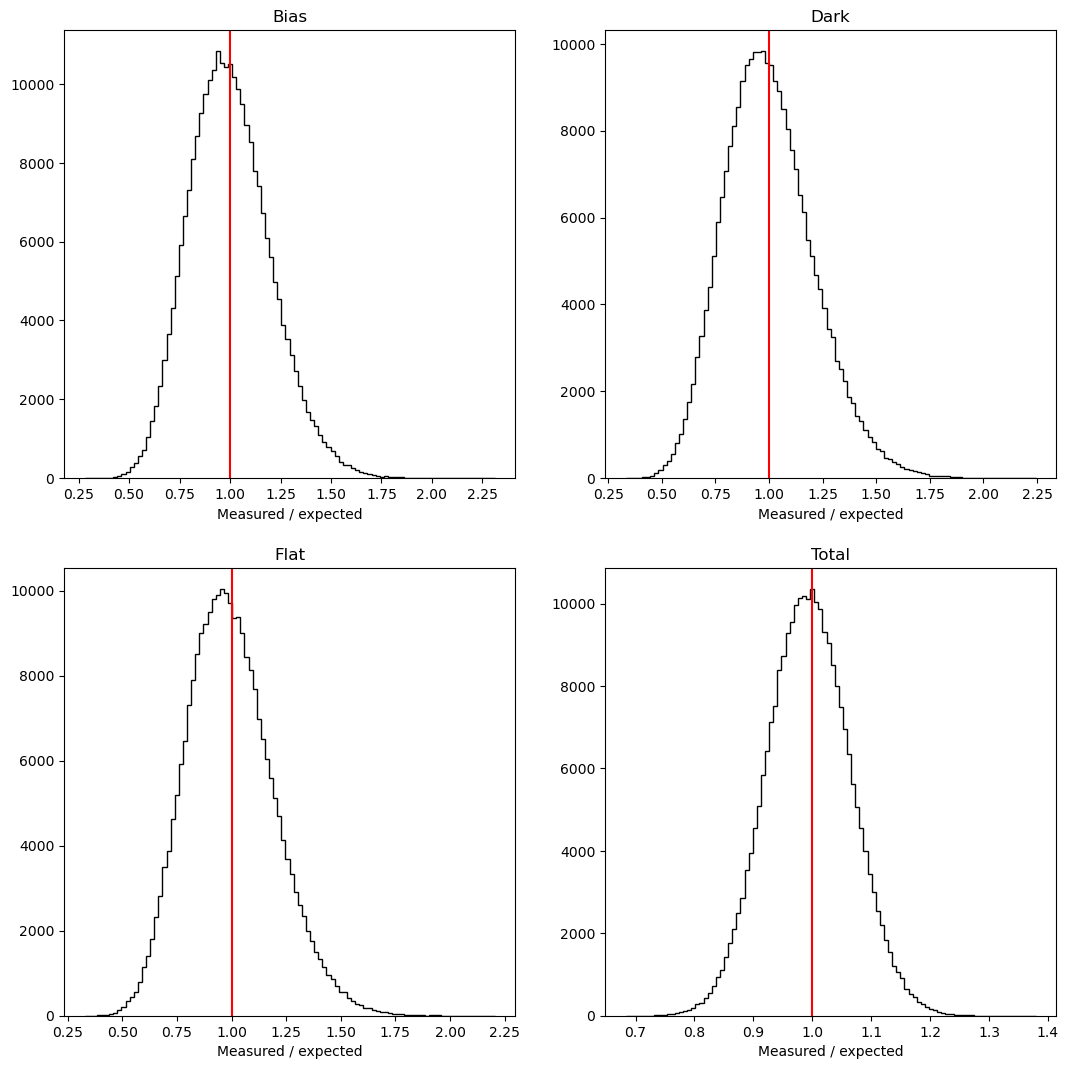

In [16]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12.8, 12.8),
    )

axes[0, 0].set_title('Bias')
axes[0, 0].hist(np.mean(bias_vars / true_bias_var, axis=0).flatten(),
        bins=100,
        histtype='step',
        color='k',
        )

axes[0, 1].set_title('Dark')
axes[0, 1].hist(np.mean(dark_vars / true_dark_var, axis=0).flatten(),
        bins=100,
        histtype='step',
        color='k',
        )

axes[1, 0].set_title('Flat')
axes[1, 0].hist(np.mean(flat_vars / effective_flat_var, axis=0).flatten(),
        bins=100,
        histtype='step',
        color='k',
        )

axes[1, 1].set_title('Total')
axes[1, 1].hist((empirical_err / measured_err).flatten(),
        bins=100,
        histtype='step',
        color='k',
        )

for ax in axes.flatten():
    ax.axvline(1, c='r', ls='-')
    ax.set_xlabel('Measured / expected')

plt.show()